In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (6).zip to archive (6).zip


In [4]:
from google.colab import files
import zipfile
import os
uploaded = files.upload()
zip_file = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')
print("Dataset extracted successfully!")
print(os.listdir('/content/dataset'))

Saving archive (6).zip to archive (6) (1).zip
Dataset extracted successfully!
['Customer Complaints Sentiment and Priority Dataset.csv']


In [5]:
import os
print(os.listdir('/content/dataset'))

['Customer Complaints Sentiment and Priority Dataset.csv']


In [6]:
import pandas as pd
df = pd.read_csv("/content/dataset/Customer Complaints Sentiment and Priority Dataset.csv")
print(df.head())
print(df.shape)
print(df.columns)

                                  Consumer_complaint  \
0  I had overdraft protection with Regions Bank i...   
1  I am the sole, legal representative of my dece...   
2  This bank has consistantly manipulated my dire...   
3  I enrolled in a Citibank checking account in X...   
4  TIAA-XXXX  has not responded to multiple reque...   

                                  Product  Sentiment  Priority  
0  Checking or savings account or service          0         1  
1  Checking or savings account or service          0         1  
2  Checking or savings account or service          0         0  
3  Checking or savings account or service          0         1  
4  Checking or savings account or service          0         1  
(1750, 4)
Index(['Consumer_complaint', 'Product', 'Sentiment', 'Priority'], dtype='object')


In [7]:
df = df.dropna()
df["Consumer_complaint"] = df["Consumer_complaint"].astype(str)
df["Consumer_complaint"] = df["Consumer_complaint"].str.lower()
print("Dataset after preprocessing:")
print(df.head())
print("\nDataset shape:", df.shape)

Dataset after preprocessing:
                                  Consumer_complaint  \
0  i had overdraft protection with regions bank i...   
1  i am the sole, legal representative of my dece...   
2  this bank has consistantly manipulated my dire...   
3  i enrolled in a citibank checking account in x...   
4  tiaa-xxxx  has not responded to multiple reque...   

                                  Product  Sentiment  Priority  
0  Checking or savings account or service          0         1  
1  Checking or savings account or service          0         1  
2  Checking or savings account or service          0         0  
3  Checking or savings account or service          0         1  
4  Checking or savings account or service          0         1  

Dataset shape: (1750, 4)


In [8]:
X = df["Consumer_complaint"]
y = df["Sentiment"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (1400, 5000)
Testing data shape: (350, 5000)


In [9]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train_tfidf, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [10]:
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.7342857142857143
Accuracy Percentage: 73.42857142857143 %


Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.98      0.85       259
           1       0.38      0.03      0.06        91

    accuracy                           0.73       350
   macro avg       0.56      0.51      0.45       350
weighted avg       0.65      0.73      0.64       350



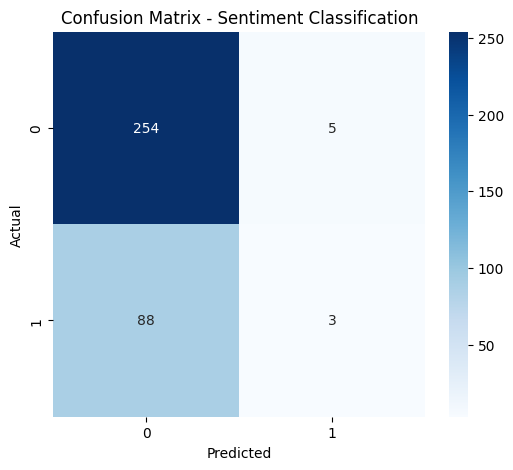

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
print("Classification Report:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Sentiment Classification")
plt.show()

In [12]:
new_complaint = input("Enter a customer complaint: ")
new_complaint = new_complaint.lower()
new_complaint_tfidf = tfidf.transform([new_complaint])
prediction = model.predict(new_complaint_tfidf)
print("Predicted Sentiment:", prediction[0])

Enter a customer complaint: My problem has not been solved and I am very unhappy.
Predicted Sentiment: 0


In [13]:
new = input("Complaint: ")
x = tfidf.transform([new.lower()])
print("Sentiment:", model.predict(x)[0])

Complaint: My complaint has not been resolved and I am unhappy.
Sentiment: 0
